# 1. Importing the libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load the data

In [26]:
# Load the CSV file
# Keep this CSV file in the same folder as the notebook

df = pd.read_csv('retail_store_inventory.csv')

# Convert date column from text to date format
df['Date'] = pd.to_datetime(df['Date'])

# Display first 5 rows
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


# 3. Basic structure check

In [27]:
# Number of rows and columns
df.shape

(73100, 15)

In [28]:
# Column names
df.columns.tolist()

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Demand Forecast',
 'Price',
 'Discount',
 'Weather Condition',
 'Holiday/Promotion',
 'Competitor Pricing',
 'Seasonality']

In [29]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64       
 14  S

In [30]:
# Random sample of rows
# This is often better than only checking the first 5 rows

df.sample(5, random_state=42)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
66127,2023-10-24,S002,P0008,Electronics,North,225,138,144,139.31,40.47,0,Snowy,1,41.97,Winter
43485,2023-03-11,S005,P0006,Toys,North,200,105,119,117.55,18.65,15,Cloudy,1,16.65,Spring
34304,2022-12-10,S001,P0005,Clothing,East,145,70,137,78.51,20.33,15,Snowy,0,18.04,Winter
34317,2022-12-10,S001,P0018,Electronics,West,350,105,157,103.11,98.65,15,Sunny,0,95.43,Spring
38631,2023-01-22,S002,P0012,Groceries,North,145,76,145,92.47,10.04,20,Sunny,0,13.01,Winter


In [31]:
data_dictionary = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str),
    "example_value": [df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else None for col in df.columns],
    "unique_values": [df[col].nunique() for col in df.columns]
})

data_dictionary

,column_name,data_type,example_value,unique_values
Date,Date,datetime64[us],2022-01-01 00:00:00,731
Store ID,Store ID,str,S001,5
Product ID,Product ID,str,P0001,20
Category,Category,str,Groceries,5
Region,Region,str,North,4
Inventory Level,Inventory Level,int64,231,451
Units Sold,Units Sold,int64,127,498
Units Ordered,Units Ordered,int64,55,181
Demand Forecast,Demand Forecast,float64,135.47,31608
Price,Price,float64,33.5,8999


# 4. Summary statistics

In [32]:
# Summary statistics for numerical columns
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


In [33]:
# Summary statistics for categorical columns
df.describe(include='object')

C:\Users\mshak\AppData\Local\Temp\ipykernel_18864\2262309595.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Store ID,Product ID,Category,Region,Weather Condition,Seasonality
count,73100,73100,73100,73100,73100,73100
unique,5,20,5,4,4,4
top,S001,P0001,Furniture,East,Sunny,Spring
freq,14620,3655,14699,18349,18290,18317


# 5. Duplicate record check

In [34]:
# Count exact duplicate rows
df.duplicated().sum()

np.int64(0)

In [35]:
# Example: check duplicate records based on business-like keys

key_columns = ['Date', 'Store ID', 'Category', 'Region']

duplicate_key_count = df.duplicated(subset=key_columns).sum()
duplicate_key_count

np.int64(26153)

# 6. Missing value analysis

In [36]:
# Count missing values
missing_count = df.isnull().sum().sort_values(ascending=False)

# Missing percentage
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage


# 7. Numerical variable analysis

In [37]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols

['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Demand Forecast',
 'Price',
 'Discount',
 'Holiday/Promotion',
 'Competitor Pricing']

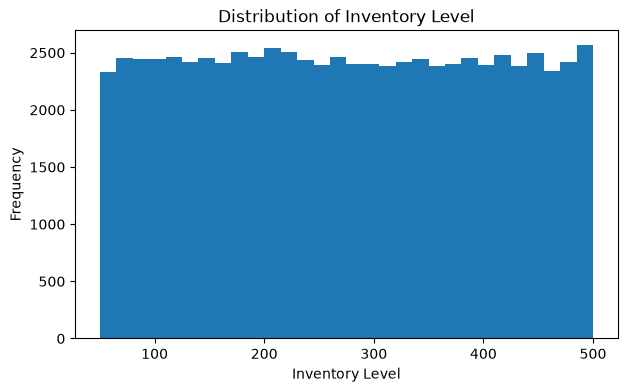

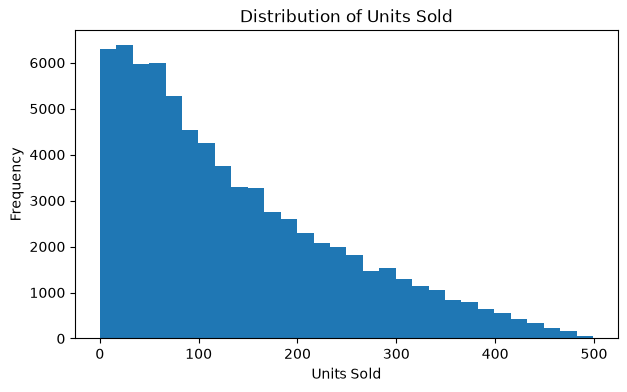

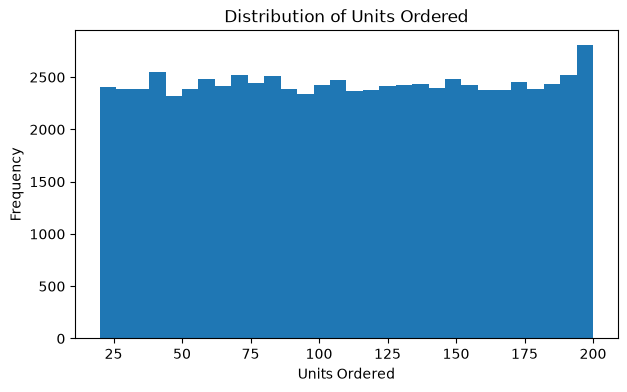

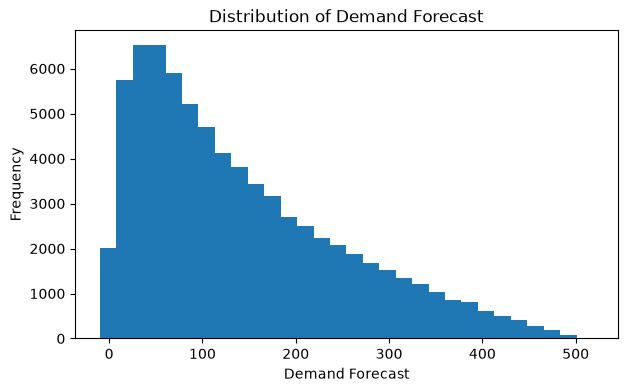

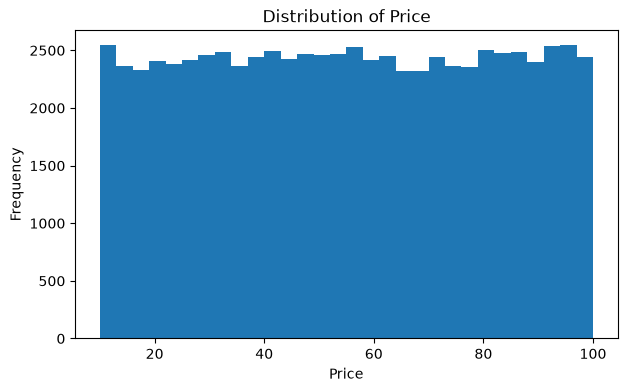

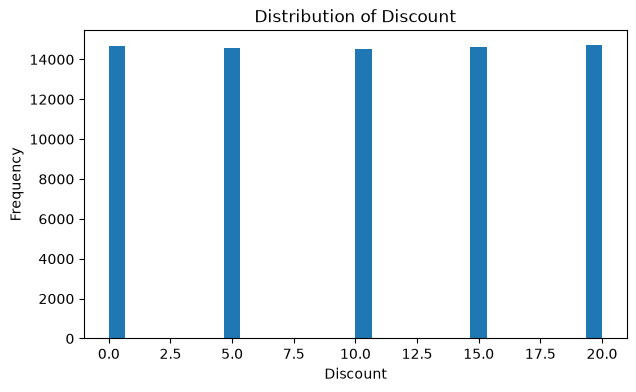

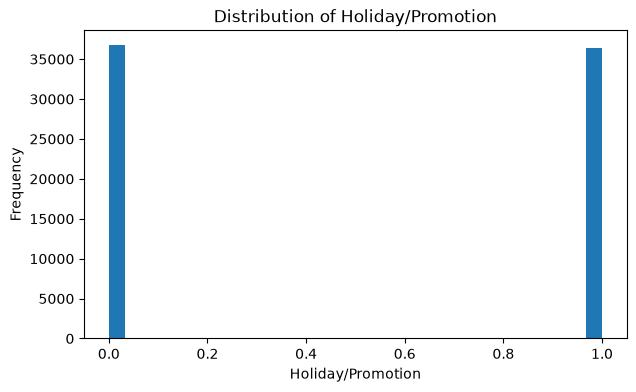

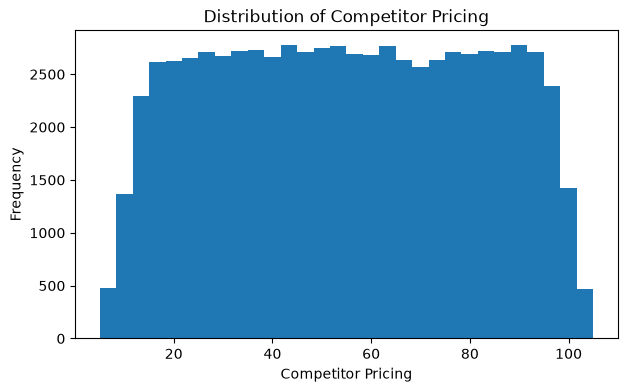

In [38]:
# Plot histograms for all numerical columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    df[col].plot(kind='hist', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# 8. Categorical variable analysis

In [39]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

C:\Users\mshak\AppData\Local\Temp\ipykernel_18864\611271536.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


['Store ID',
 'Product ID',
 'Category',
 'Region',
 'Weather Condition',
 'Seasonality']

In [40]:
# Frequency count for each categorical column

for col in categorical_cols:
    print("\nColumn:", col)
    print(df[col].value_counts())


Column: Store ID
Store ID
S001    14620
S002    14620
S003    14620
S004    14620
S005    14620
Name: count, dtype: int64

Column: Product ID
Product ID
P0001    3655
P0002    3655
P0003    3655
P0004    3655
P0005    3655
P0006    3655
P0007    3655
P0008    3655
P0009    3655
P0010    3655
P0011    3655
P0012    3655
P0013    3655
P0014    3655
P0015    3655
P0016    3655
P0017    3655
P0018    3655
P0019    3655
P0020    3655
Name: count, dtype: int64

Column: Category
Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

Column: Region
Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64

Column: Weather Condition
Weather Condition
Sunny     18290
Rainy     18278
Snowy     18272
Cloudy    18260
Name: count, dtype: int64

Column: Seasonality
Seasonality
Spring    18317
Summer    18305
Winter    18285
Autumn    18193
Name: count, dtype: int64


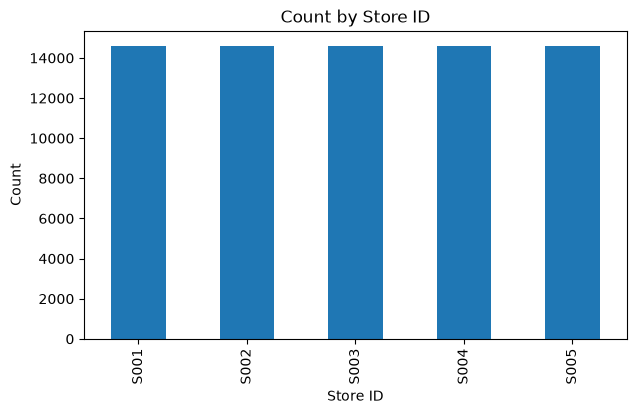

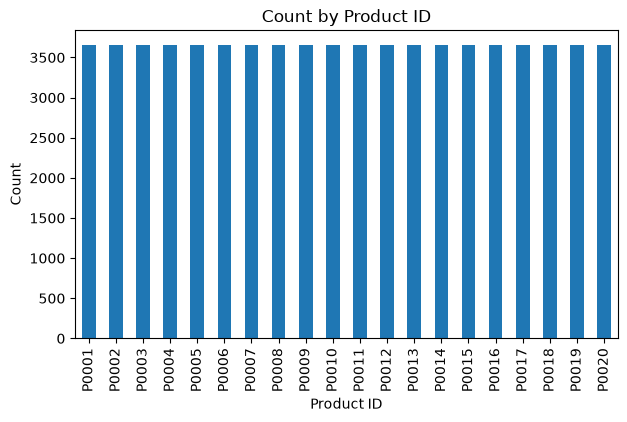

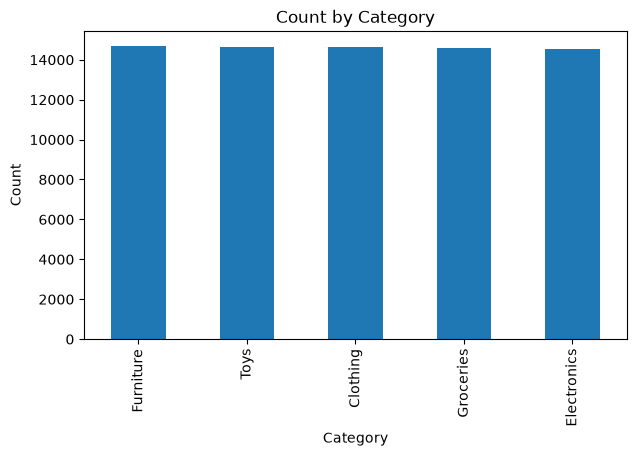

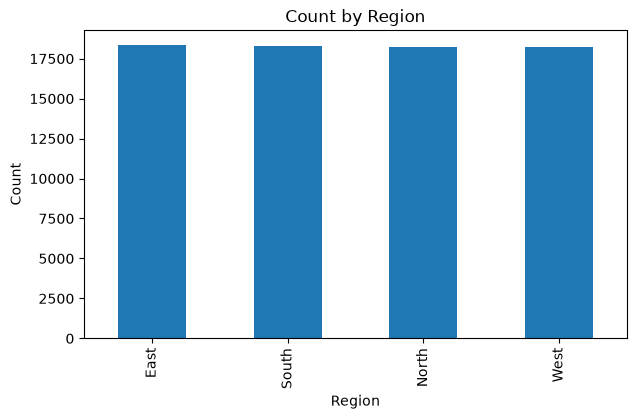

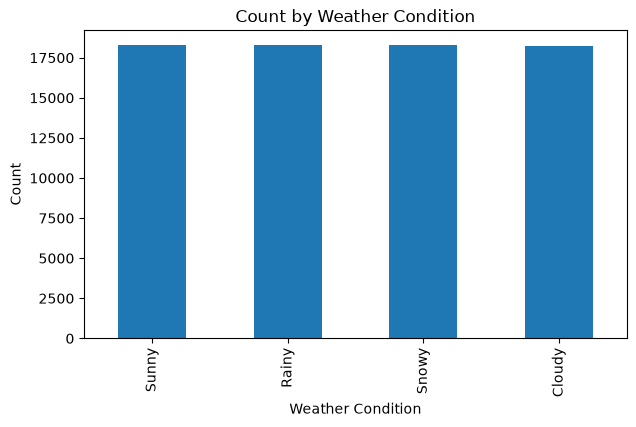

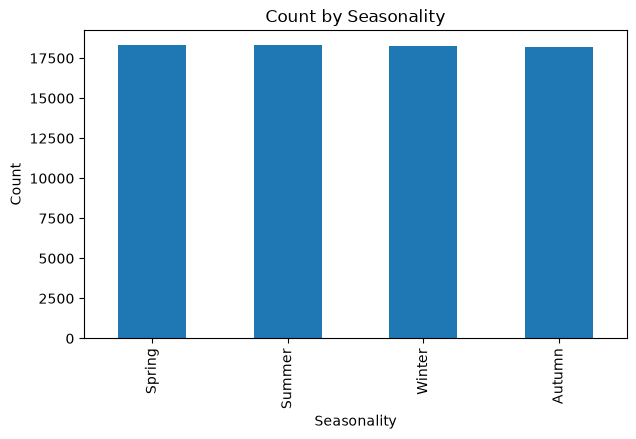

In [41]:
# Bar chart for key categorical columns

for col in ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']:
    plt.figure(figsize=(7, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# 9. Outlier detection

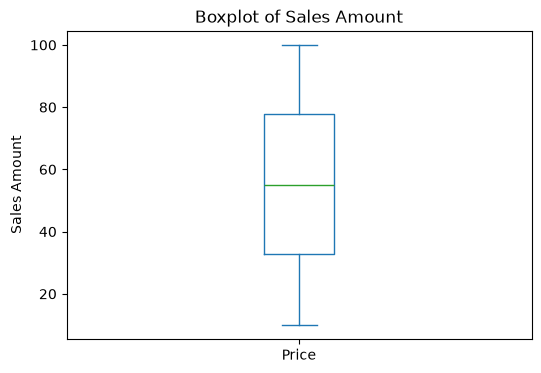

In [42]:
# Boxplot for sales_amount

plt.figure(figsize=(6, 4))
df['Price'].plot(kind='box')
plt.title('Boxplot of Sales Amount')
plt.ylabel('Sales Amount')
plt.show()